In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from patsy import dmatrices
import numpy as np

In [6]:
!pip install statsmodels

In [7]:
df =pd.read_csv(r"pixel_2023_ndvi_data.csv")

In [8]:
df_clean = df.dropna()

C:\Users\omkar\AppData\Local\Temp\ipykernel_26996\1149068710.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Date_str"] = df.Date.astype(str)


(0.0, 1.0)

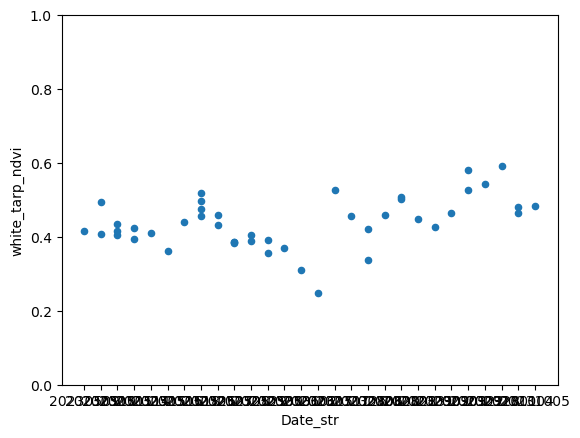

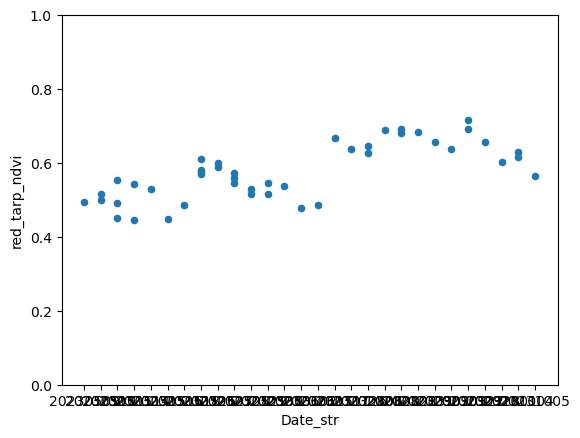

In [9]:
df_clean["Date_str"] = df.Date.astype(str)
x = "Date_str"
y1 = "white_tarp_ndvi"
y2 = "red_tarp_ndvi"
df_clean.plot(x,y1, kind = 'scatter')
plt.ylim([0,1])
df_clean.plot(x,y2,  kind = 'scatter')
plt.ylim([0,1])

(0.0, 1.0)

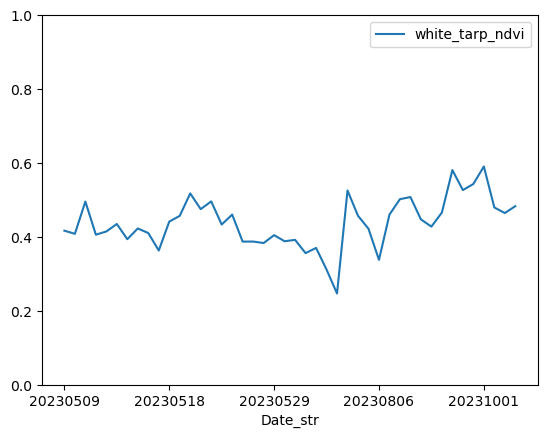

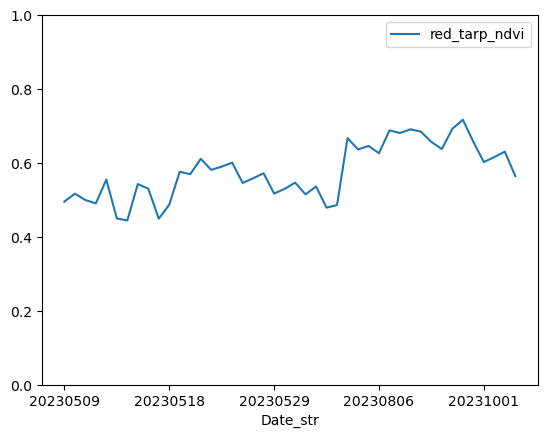

In [10]:
df_clean.plot(x,y1)
plt.ylim([0,1])
df_clean.plot(x,y2)
plt.ylim([0,1])

(0.0, 1.0)

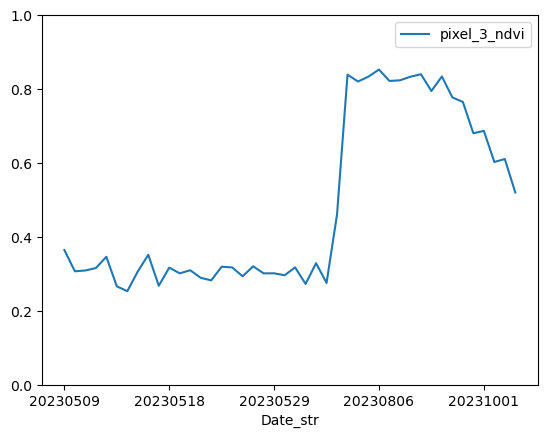

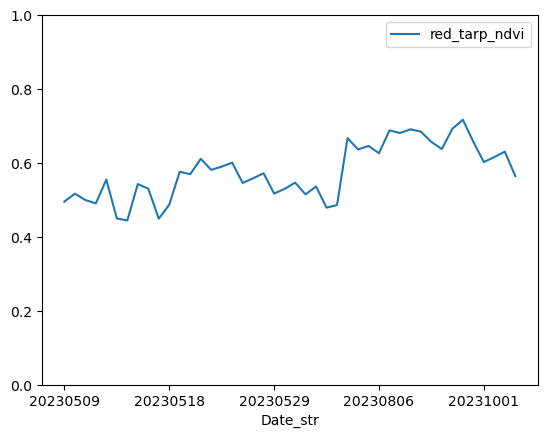

In [11]:
df_clean.plot(x,'pixel_3_ndvi')
plt.ylim([0,1])
df_clean.plot(x,y2)
plt.ylim([0,1])

In [12]:
df_clean['Date_date'] = pd.to_datetime(df_clean['Date_str'], format = "%Y%m%d" )
df_clean['DOY'] = df_clean['Date_date'].dt.dayofyear
df_clean.head()

C:\Users\omkar\AppData\Local\Temp\ipykernel_26996\3437731591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Date_date'] = pd.to_datetime(df_clean['Date_str'], format = "%Y%m%d" )
C:\Users\omkar\AppData\Local\Temp\ipykernel_26996\3437731591.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['DOY'] = df_clean['Date_date'].dt.dayofyear


,Date,Acquisition_Time,Satellite_ID,Product_Level,white_tarp_ndvi,red_tarp_ndvi,pixel_1_ndvi,pixel_2_ndvi,pixel_3_ndvi,pixel_4_ndvi,...,pixel_11_ndvi,pixel_12_ndvi,pixel_13_ndvi,pixel_14_ndvi,pixel_15_ndvi,pixel_16_ndvi,pixel_17_ndvi,Date_str,Date_date,DOY
0,20230509,155405,2402,3B,0.416805,0.495419,0.363048,0.349359,0.364238,0.388557,...,0.320088,0.343145,0.350923,0.403608,0.354223,0.314654,0.319491,20230509,2023-05-09,129
1,20230510,154308,241c,3B,0.408255,0.516883,0.276268,0.274854,0.306964,0.326786,...,0.270278,0.252770,0.268943,0.357284,0.351960,0.242804,0.233674,20230510,2023-05-10,130
2,20230510,154310,241c,3B,0.495527,0.499682,0.291716,0.277869,0.309116,0.300325,...,0.259517,0.261300,0.283847,0.323169,0.327417,0.282420,0.247138,20230510,2023-05-10,130
3,20230511,150441,24b4,3B,0.406004,0.490724,0.292171,0.305395,0.315642,0.345270,...,0.277361,0.259016,0.283329,0.314654,0.308998,0.277778,0.295455,20230511,2023-05-11,131
4,20230511,150443,24b4,3B,0.414608,0.555144,0.331974,0.318234,0.346171,0.395028,...,0.266448,0.266169,0.280061,0.313202,0.324135,0.288457,0.296600,20230511,2023-05-11,131


In [14]:
df_clean.info()
df_tarp_0N_pix = df_clean[["Date_date","DOY","white_tarp_ndvi","red_tarp_ndvi","pixel_2_ndvi","pixel_4_ndvi","pixel_9_ndvi","pixel_10_ndvi","pixel_12_ndvi","pixel_17_ndvi"]]
df_tarp_50N_pix = df_clean[["Date_date","DOY","white_tarp_ndvi","red_tarp_ndvi","pixel_1_ndvi","pixel_5_ndvi","pixel_8_ndvi","pixel_11_ndvi","pixel_13_ndvi","pixel_16_ndvi"]]
df_tarp_100N_pix = df_clean[["Date_date","DOY","white_tarp_ndvi","red_tarp_ndvi","pixel_3_ndvi","pixel_6_ndvi","pixel_7_ndvi","pixel_14_ndvi","pixel_15_ndvi"]]

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 44
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              44 non-null     int64         
 1   Acquisition_Time  44 non-null     int64         
 2   Satellite_ID      44 non-null     object        
 3   Product_Level     44 non-null     object        
 4   white_tarp_ndvi   44 non-null     float64       
 5   red_tarp_ndvi     44 non-null     float64       
 6   pixel_1_ndvi      44 non-null     float64       
 7   pixel_2_ndvi      44 non-null     float64       
 8   pixel_3_ndvi      44 non-null     float64       
 9   pixel_4_ndvi      44 non-null     float64       
 10  pixel_5_ndvi      44 non-null     float64       
 11  pixel_6_ndvi      44 non-null     float64       
 12  pixel_7_ndvi      44 non-null     float64       
 13  pixel_8_ndvi      44 non-null     float64       
 14  pixel_9_ndvi      44 non-null    

In [15]:
mod0 = ols('red_tarp_ndvi ~ DOY', data=df_tarp_0N_pix)
res = mod0.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          red_tarp_ndvi   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     58.96
Date:                Sun, 16 Mar 2025   Prob (F-statistic):           1.58e-09
Time:                        13:18:11   Log-Likelihood:                 71.478
No. Observations:                  44   AIC:                            -139.0
Df Residuals:                      42   BIC:                            -135.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3832      0.026     14.597      0.0

In [16]:
mod50 = ols('white_tarp_ndvi ~ DOY', data=df_tarp_50N_pix)
res50 = mod50.fit()
print(res50.summary())

                            OLS Regression Results                            
Dep. Variable:        white_tarp_ndvi   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     16.46
Date:                Sun, 16 Mar 2025   Prob (F-statistic):           0.000211
Time:                        13:18:12   Log-Likelihood:                 63.482
No. Observations:                  44   AIC:                            -123.0
Df Residuals:                      42   BIC:                            -119.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3159      0.031     10.035      0.0

In [17]:
mod100 = ols('red_tarp_ndvi ~ pixel_3_ndvi', data=df_tarp_100N_pix)
res100 = mod100.fit()
print(res100.summary())

                            OLS Regression Results                            
Dep. Variable:          red_tarp_ndvi   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     98.80
Date:                Sun, 16 Mar 2025   Prob (F-statistic):           1.34e-12
Time:                        13:18:12   Log-Likelihood:                 78.794
No. Observations:                  44   AIC:                            -153.6
Df Residuals:                      42   BIC:                            -150.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4461      0.015     30.669   

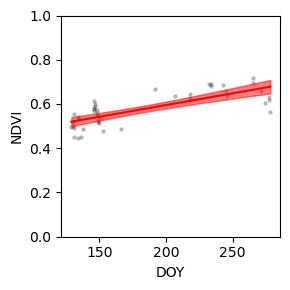

In [18]:
# regression for ndvi
res_am = ols('red_tarp_ndvi ~ DOY', data=df_tarp_0N_pix).fit()

fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot()
# raw data
x = df_tarp_0N_pix.DOY.values
y = df_tarp_0N_pix.red_tarp_ndvi.values
#print(x)
#print(y)
ax.scatter(x,y,s=5,alpha=0.2,c='k')
# regression lines
plot_x = pd.DataFrame(
    np.linspace(np.amin(x), np.amax(x),len(x)),
    columns=['DOY'])
plot_y = res_am.get_prediction(plot_x).summary_frame()
#print(plot_x)
#print(plot_y)
ax.plot(plot_x['DOY'].values,
        plot_y['mean'].values,c='r')
ax.fill_between(plot_x['DOY'].values,
                plot_y['mean_ci_lower'].values,
                plot_y['mean_ci_upper'].values,
                color='r',alpha=0.5)
ax.set_xlabel('DOY')
ax.set_ylabel('NDVI')
ax.set_ylim([0,1])
fig.tight_layout()

(-1.0, 1.0)

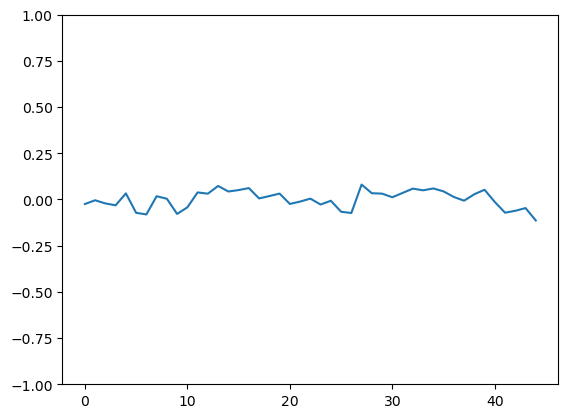

In [19]:
res_am.resid.plot()
plt.ylim([-1,1])


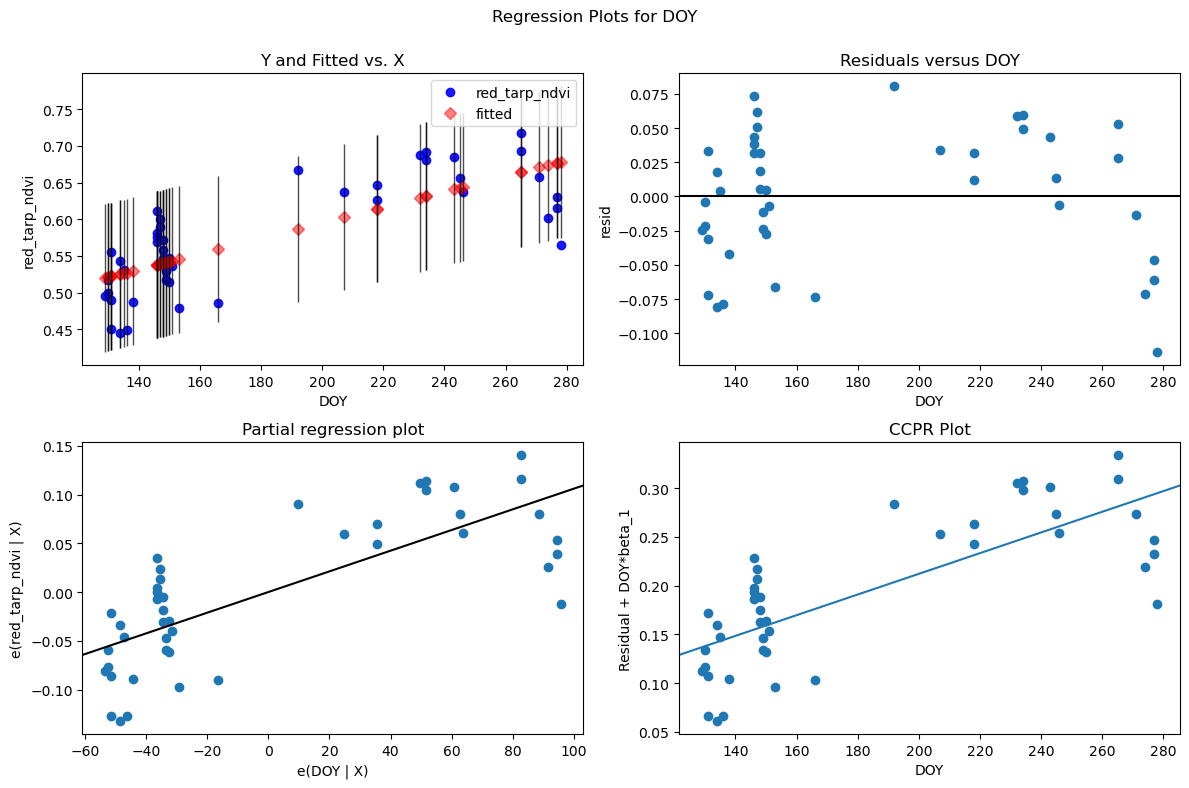

In [20]:
#define figure size
fig = plt.figure(figsize=(12,8))

#produce regression plots
fig = sm.graphics.plot_regress_exog(res, 'DOY', fig=fig)

In [21]:
resid_red =res.resid.values
df_tarp_0N_pix["resid_red"] = resid_red
df_tarp_0N_pix.head()

C:\Users\omkar\AppData\Local\Temp\ipykernel_26996\2130336037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tarp_0N_pix["resid_red"] = resid_red


,Date_date,DOY,white_tarp_ndvi,red_tarp_ndvi,pixel_2_ndvi,pixel_4_ndvi,pixel_9_ndvi,pixel_10_ndvi,pixel_12_ndvi,pixel_17_ndvi,resid_red
0,2023-05-09,129,0.416805,0.495419,0.349359,0.388557,0.312048,0.387286,0.343145,0.319491,-0.024640
1,2023-05-10,130,0.408255,0.516883,0.274854,0.326786,0.240732,0.314329,0.252770,0.233674,-0.004236
2,2023-05-10,130,0.495527,0.499682,0.277869,0.300325,0.243216,0.349637,0.261300,0.247138,-0.021437
3,2023-05-11,131,0.406004,0.490724,0.305395,0.345270,0.264670,0.300590,0.259016,0.295455,-0.031456
4,2023-05-11,131,0.414608,0.555144,0.318234,0.395028,0.275474,0.301647,0.266169,0.296600,0.032964


In [22]:
df_tarp_0N_pix["pix_2_red_cor_plus"] = df_tarp_0N_pix['pixel_2_ndvi'] + df_tarp_0N_pix['resid_red']
df_tarp_0N_pix["pix_2_red_cor_minus"] = df_tarp_0N_pix['pixel_2_ndvi'] - df_tarp_0N_pix['resid_red']


C:\Users\omkar\AppData\Local\Temp\ipykernel_26996\3634934506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tarp_0N_pix["pix_2_red_cor_plus"] = df_tarp_0N_pix['pixel_2_ndvi'] + df_tarp_0N_pix['resid_red']
C:\Users\omkar\AppData\Local\Temp\ipykernel_26996\3634934506.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tarp_0N_pix["pix_2_red_cor_minus"] = df_tarp_0N_pix['pixel_2_ndvi'] - df_tarp_0N_pix['resid_red']


<Axes: xlabel='DOY'>

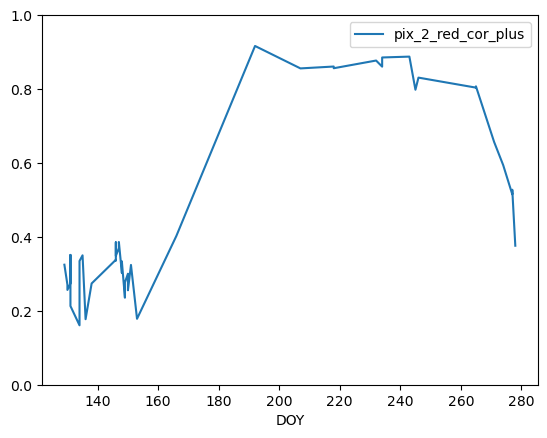

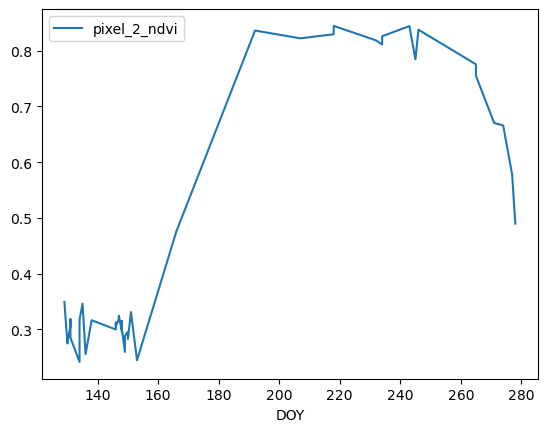

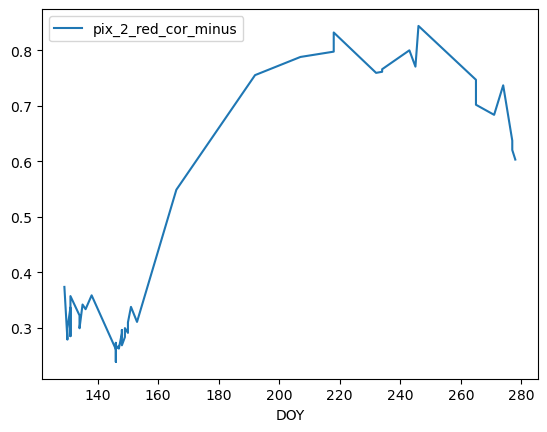

In [23]:
df_tarp_0N_pix.plot('DOY','pix_2_red_cor_plus')
plt.ylim([0,1])
df_tarp_0N_pix.plot('DOY','pixel_2_ndvi')
df_tarp_0N_pix.plot('DOY','pix_2_red_cor_minus')

In [24]:
df_tarp_0N_pix

,Date_date,DOY,white_tarp_ndvi,red_tarp_ndvi,pixel_2_ndvi,pixel_4_ndvi,pixel_9_ndvi,pixel_10_ndvi,pixel_12_ndvi,pixel_17_ndvi,resid_red,pix_2_red_cor_plus,pix_2_red_cor_minus
0,2023-05-09,129,0.416805,0.495419,0.349359,0.388557,0.312048,0.387286,0.343145,0.319491,-0.024640,0.324719,0.373999
1,2023-05-10,130,0.408255,0.516883,0.274854,0.326786,0.240732,0.314329,0.252770,0.233674,-0.004236,0.270618,0.279090
2,2023-05-10,130,0.495527,0.499682,0.277869,0.300325,0.243216,0.349637,0.261300,0.247138,-0.021437,0.256431,0.299306
3,2023-05-11,131,0.406004,0.490724,0.305395,0.345270,0.264670,0.300590,0.259016,0.295455,-0.031456,0.273939,0.336851
4,2023-05-11,131,0.414608,0.555144,0.318234,0.395028,0.275474,0.301647,0.266169,0.296600,0.032964,0.351198,0.285270
5,2023-05-11,131,0.434902,0.449909,0.285203,0.282782,0.243885,0.277279,0.239686,0.268409,-0.072271,0.212933,0.357474
6,2023-05-14,134,0.393714,0.444444,0.241647,0.280615,0.235989,0.265065,0.223839,0.228394,-0.080918,0.160728,0.322565
7,2023-05-14,134,0.422846,0.542968,0.317116,0.356379,0.263996,0.303759,0.285223,0.260541,0.017605,0.334721,0.299511
8,2023-05-15,135,0.410377,0.530344,0.346188,0.380282,0.325516,0.346667,0.324363,0.328751,0.003920,0.350108,0.342268
9,2023-05-16,136,0.363141,0.449211,0.255551,0.301945,0.218462,0.263817,0.229512,0.242596,-0.078274,0.177277,0.333825
